In [6]:
#  {i:chr(i) for i in range(256)}

charmap = {
 32: 0b000000000, #' ',
 33: 0b010010010, #'!',
 34: 0b101000000, #'"',
 39: 0b010000000, #"'",
 40: 0b111100111, #'(',
 41: 0b111001111, #')',
 42: 0b010111010, #'*',
 43: 0b010111010, #'+',
 44: 0b000000010, #',',
 45: 0b000111000, #'-',
 46: 0b000000010, #'.',
 47: 0b001010100, #'/',
 48: 0b111101111, # '0',
 49: 0b110010111, # '1',
 50: 0b110010011, # '2',
 51: 0b110011110, # '3',
 52: 0b101111001, # '4',
 53: 0b011010110, # '5',
 54: 0b100111111, # '6',
 55: 0b111001001, # '7',
 56: 0b111111111, # '8',
 57: 0b111111001, # '9',
 58: 0b010000010, # ':',
 59: 0b010000110, # ';',
 60: 0b010100010, #'<',
 61: 0b111000111, # '=',
 62: 0b010001100, # '>',
 65: 0b010111101, # 'A',
 66: 0b110111110, #'B'
 67: 0b011100011, #'C'
 68: 0b110101110, #'D'
 69: 0b111000111, #'E'
 70: 0b111110100, #'F'
 71: 0b110101111, #'G'
 72: 0b101111101, #'H'
 73: 0b111010111, #'I'
 74: 0b001001110, #'J'
 75: 0b101110101, #'K'
 76: 0b100100111, #'L'
 77: 0b111111101, #'M'
 78: 0b110101101, #'N'
 79: 0b111101111, #'O'
 80: 0b111111100, #'P'
 81: 0b111101110, #'Q'
 82: 0b110111101, #'R'
 83: 0b011010110, #'S'
 84: 0b111010010, #'T'
 85: 0b101101111, #'U'
 86: 0b101101011, #'V'
 87: 0b101111111, #'W'
 88: 0b101010101, #'X'
 89: 0b101010010, #'Y'
 90: 0b110010011, #'Z'
 91: 0b111100111, #'[',
 92: 0b100010001, #'\\',
 93: 0b111001111, #']',
 94: 0b010101000, #'^',
 95: 0b000000111, #'_',
 96: 0b010000000, #'`',
 97: 0b010111101, #'a',
 98: 0b110111110, #'b',
 99: 0b011100011, #'c',
 100: 0b110101110, #'d',
 101: 0b111000111, #'e',
 102: 0b111110100, #'f',
 103: 0b110101111, #'g',
 104: 0b101111101, #'h',
 105: 0b111010111, #'i',
 106: 0b001001110, #'j',
 107: 0b101110101, #'k',
 108: 0b100100111, #'l',
 109: 0b111111101, #'m',
 110: 0b110101101, #'n',
 111: 0b111101111, #'o',
 112: 0b111111100, #'p',
 113: 0b111101110, #'q',
 114: 0b110111101, #'r',
 115: 0b011010110, #'s',
 116: 0b111010010, #'t',
 117: 0b101101111, #'u',
 118: 0b101101011, #'v',
 119: 0b101111111, #'w',
 120: 0b101010101, #'x',
 121: 0b101010010, #'y',
 122: 0b110010011, #'z',
#  123: '{',
#  124: '|',
#  125: '}',
#  126: '~'
    176: 0b011011000, #,
 }

02:00:07


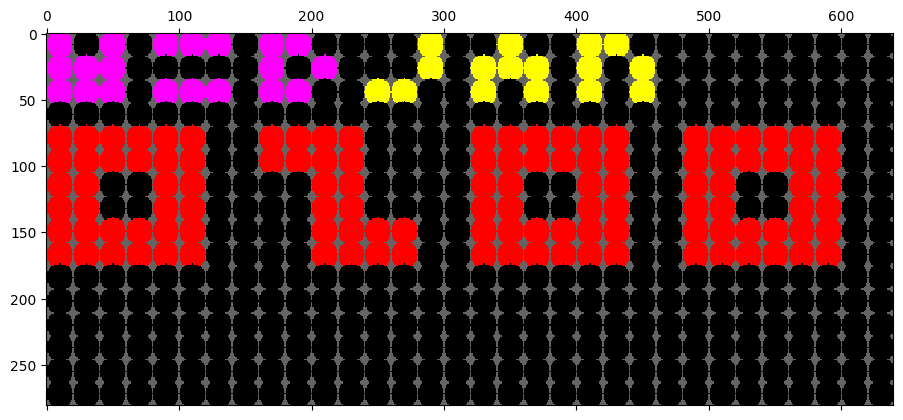

In [53]:
import matplotlib.pyplot as plt
import datetime
import numpy as np
import cv2

height, width = 16, 32
NUM_LEDS = height * width
screen = np.zeros((height, width,3), np.uint8)

def show():
    upscale = 4
    pitch_x = 5.0 * upscale
    pitch_y = 4.4 * upscale
    image = np.ones((int(pitch_y * height), int(pitch_x * width), 3), np.uint8) * 100

    for x in range(width):
        for y in range(height):
            color = (int(screen[y,x][0]), int(screen[y,x][1]), int(screen[y,x][2]))
            cv2.circle(image, (int(x * pitch_x + pitch_x/2), int(y * pitch_y + pitch_y/2)), 10, color, -1)
    plt.matshow(image)

 
def setPixel(x, y,  col) : 
    if x >= 0 and x < width and y >=0 and y < height:
        screen[y,x] = col

def putChar(n,x,y, scale=1, col = 255):
    C = 511

    if ord(n) in charmap:
        C = charmap[ord(n)]

    i = 1
    for dy in [2,1,0]: 
        for dx in [2,1,0]:
            if i & C > 0:
                for ddx in range(scale):
                    for ddy in range(scale):
                        setPixel(x + dx*scale + ddx, y + dy*scale + ddy, col)
            i = i << 1

now = datetime.datetime.now()
timestring = now.strftime("%H:%M:%S")
print(timestring)

for i, a in enumerate("wed"):
    putChar(a, i*4, 0, 1, (255,0,255))

for i, a in enumerate("jan"):
    putChar(a, i*4+12, 0, 1, (255,255,0))

for i, a in enumerate(timestring[:2]):
    putChar(a, i*8, 4, 2, (255,0,0))

for i, a in enumerate(timestring[3:5]):
    putChar(a, i*8 + 16, 4, 2, (255,0,0))

show()

In [21]:
!pip3 install opencv-python

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 33.1 MB 1.5 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
